In [1]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr

## Cluster GOF

In [2]:
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean.tpm.max(dim="time", skipna=True) >= 1).all(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)
ds_filtered = ds.sel(ensembl_gene_id=mask)

traj120 = xr.load_dataarray("clustering/results/all_gene_trajectories_120.nc")
gof120 = pd.read_csv("clustering/results/gof_trajectories_120.csv")
print("n genes: ",(gof120.ensembl_gene_id.nunique()))
gof120.groupby("source").sum("accepted") / gof120.groupby("source").count().drop(columns="ensembl_gene_id")

n genes:  23428


,nrmse,accepted
source,,
BK,0.137117,0.867850
JN,0.170310,0.717176
Pauli,0.226143,0.500470
White,0.158139,0.733908


<Axes: xlabel='nrmse', ylabel='Density'>

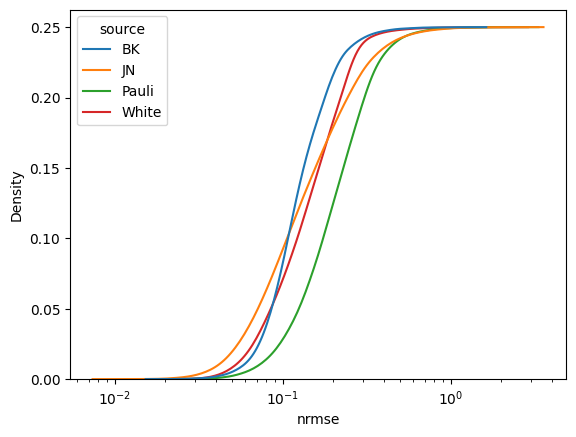

In [3]:
sns.kdeplot(gof120, x="nrmse", hue="source", log_scale=True, cumulative=True)

Mean NRMSE:  source
BK       0.137117
JN       0.170310
Pauli    0.226143
White    0.158139
Name: nrmse, dtype: float64 



<Axes: title={'center': 'Accepted NRMSE by Source (120h)'}, ylabel='Source'>

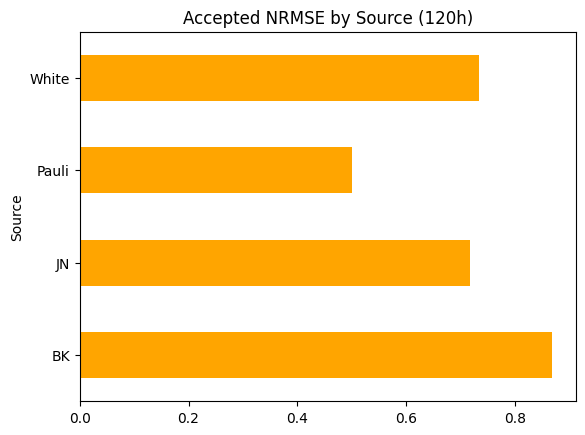

In [4]:
print("Mean NRMSE: ", gof120.groupby("source").nrmse.mean(), "\n")
gof120.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (120h)")
plt.close()
(gof120.groupby("source").accepted.sum() / gof120.groupby("source").count()["ensembl_gene_id"]).plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (120h)")

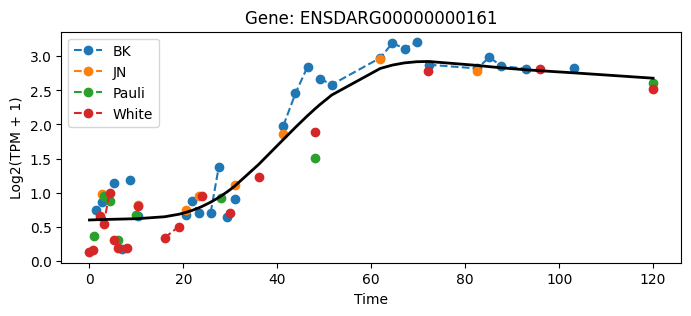

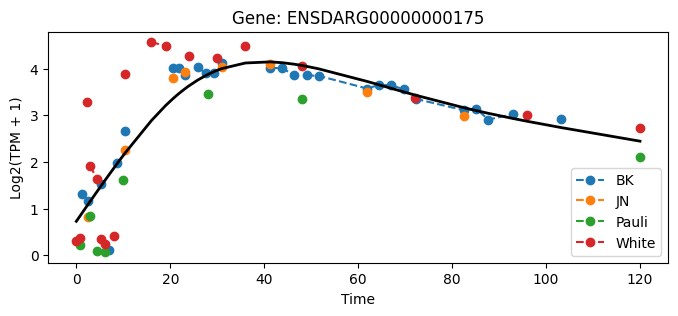

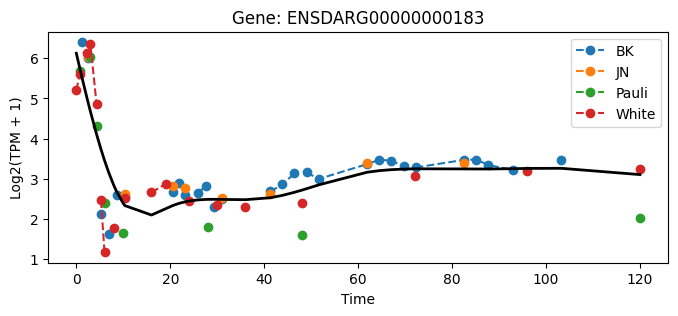

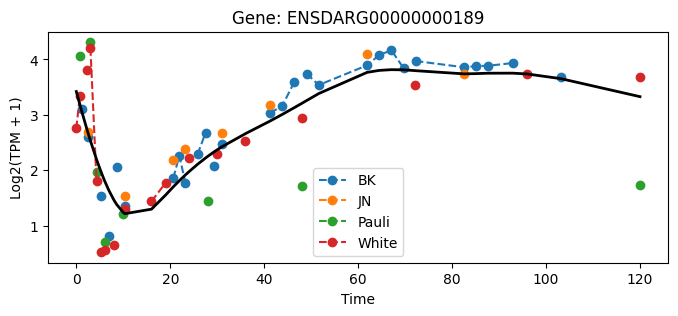

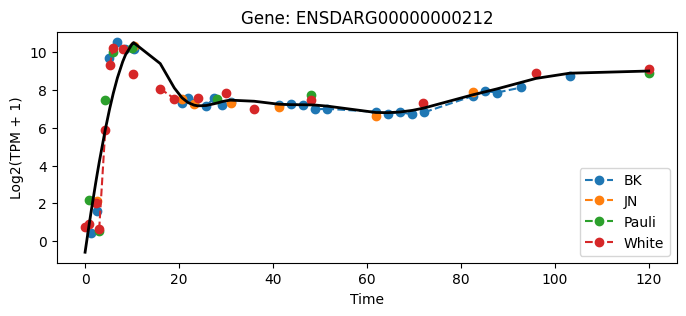

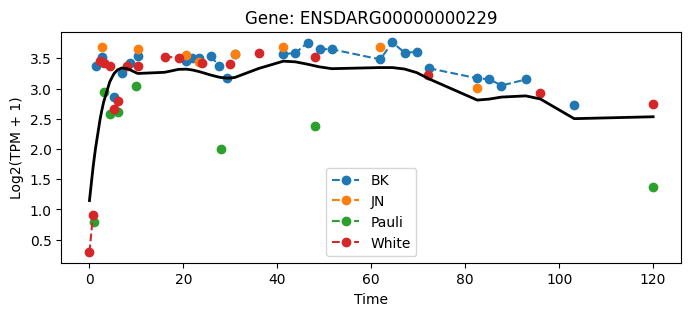

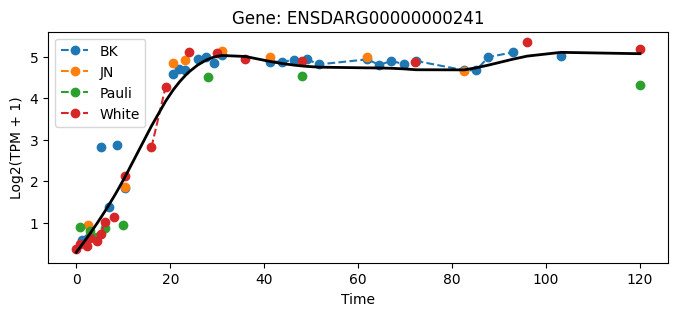

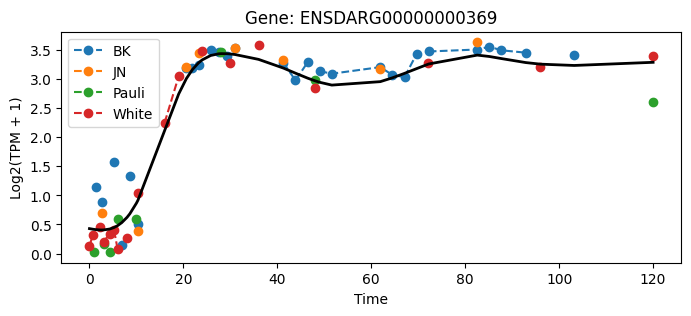

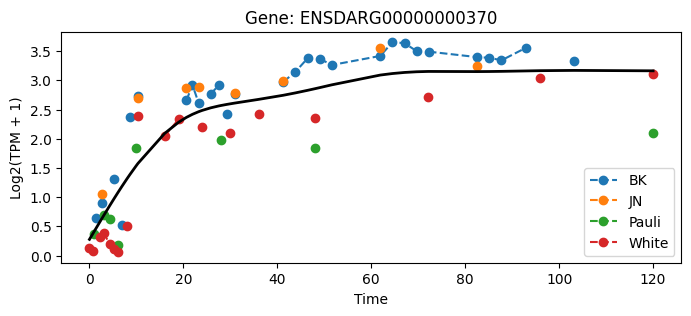

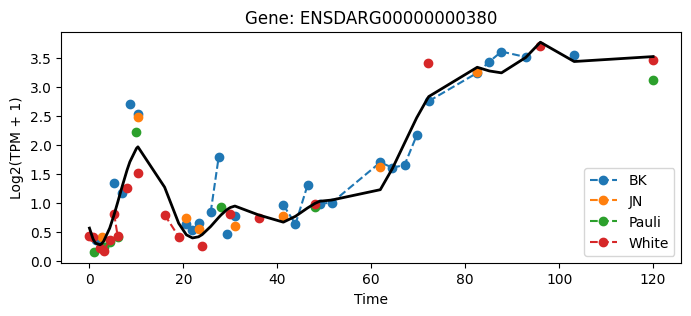

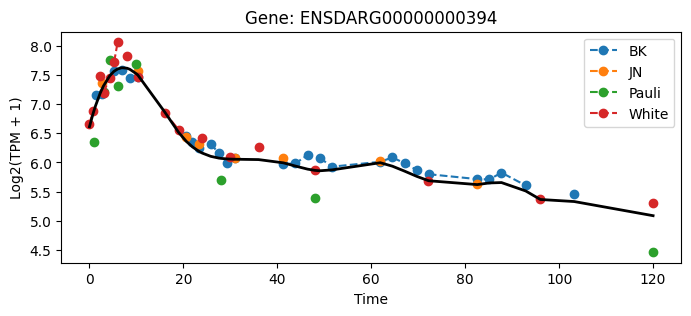

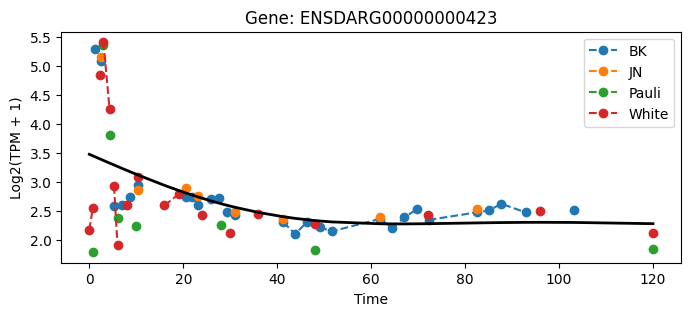

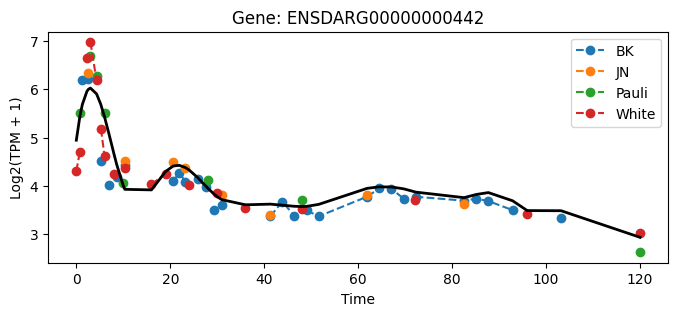

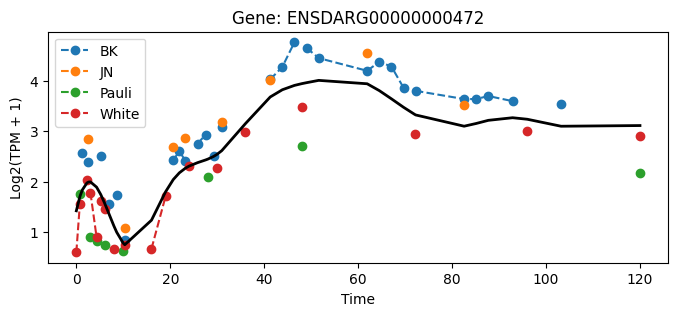

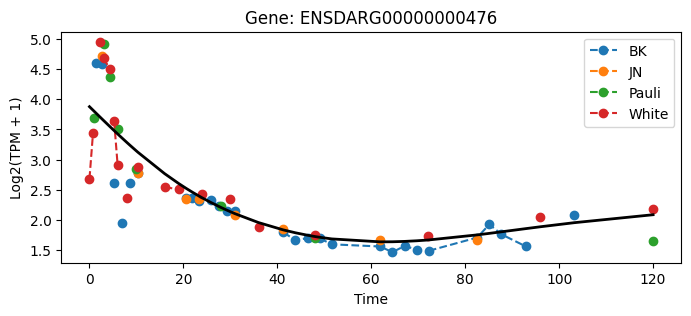

In [8]:
sc = ds.source.values

for g in traj120.ensembl_gene_id.values[10:25]:
    y_true = ds_filtered.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj120.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8, 3))
    plt.plot(ds_filtered.time, y_true, marker="o", ls="--", label=sc)
    plt.plot(ds_filtered.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

### Cluster center GOF

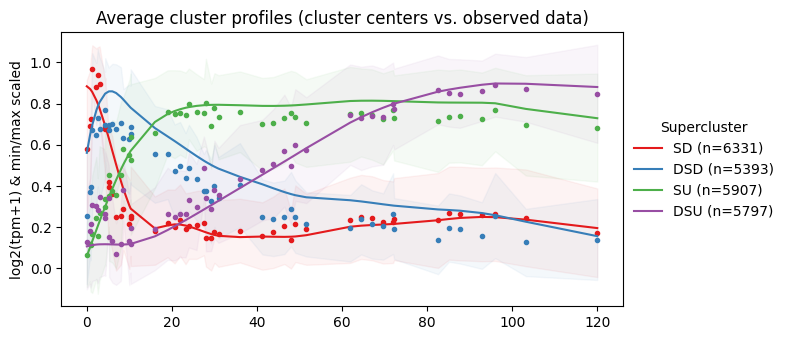

,supercluster,RMSE,r2,spearmanr,pearsonr
0,0,0.097475,0.839387,0.911261,0.920985
1,1,0.136730,0.593429,0.942377,0.962900
2,2,0.055821,0.948427,0.768355,0.985036
3,3,0.092485,0.899773,0.876110,0.968732


In [5]:
def minmax(curve):
    mn = curve.min("time")
    mx = curve.max("time")
    return (curve - mn) / (mx - mn)

def zscore(curve):
    sd = curve.std("time")
    return (curve - curve.mean("time")) / sd

def rmse(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return np.sqrt(np.mean((a[mask] - b[mask])**2)).item()

def r2(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
    ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
    return (1 - ss_res/ss_tot).item()

fuzzy_cntr = xr.load_dataarray("clustering/results/all_superclusters_centers.nc")
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
colors = sns.color_palette("Set1", 5)

plt.figure(figsize=(8,3.5))
for c in range(fuzzy_cntr.shape[0]):

    gene_ids = labels['ensembl_gene_id'][labels['supercluster'] == c].values

    ds_c = ds.sel(ensembl_gene_id=gene_ids)
    ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
    ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", "source"))
    #ds_c = zscore(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
    center = fuzzy_cntr[c, :]

    plt.plot(fuzzy_cntr.time, center, label=f"{cluster_map[c]} (n={ds_c.ensembl_gene_id.size})", c=colors[c])
    plt.plot(ds_c_mean.time, ds_c_mean, ".", c=colors[c])
    plt.fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=colors[c])

    gof.append({"supercluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
   
pd.DataFrame(gof).to_excel("clustering/cluster_validation.xlsx")
    
plt.title("Average cluster profiles (cluster centers vs. observed data)")
plt.ylabel("log2(tpm+1) & min/max scaled")
plt.legend(loc=(1.01, 0.3), frameon=False, title="Supercluster")
plt.tight_layout()
plt.savefig("clustering/figs/cluster_validation.png", dpi=300)
plt.show()
pd.DataFrame(gof)

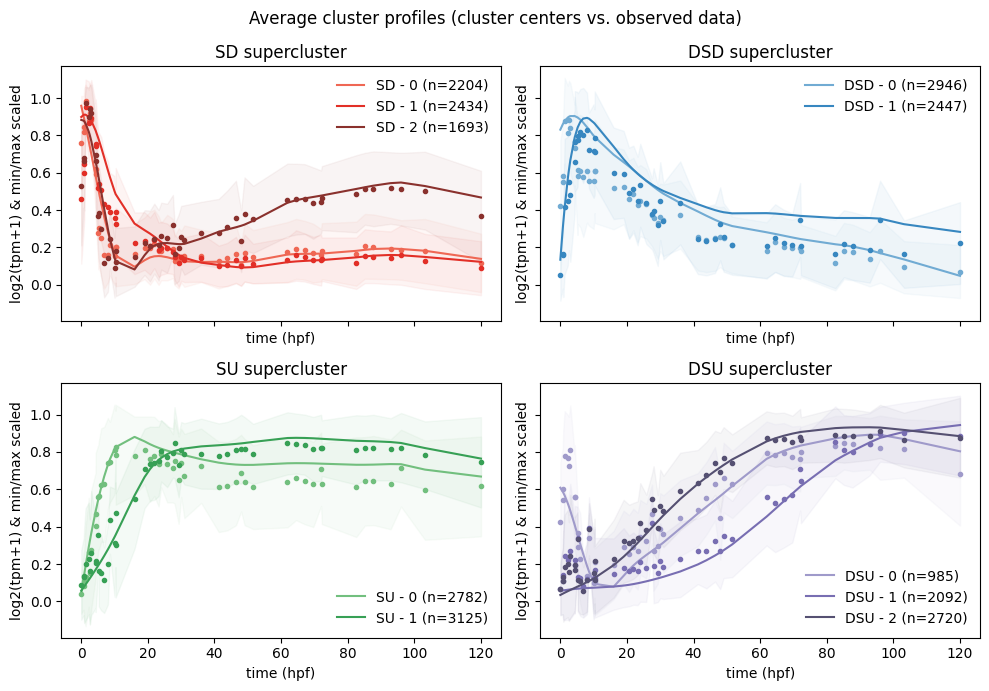

,supercluster,subcluster,RMSE,r2,spearmanr,pearsonr
0,0,0,0.085769,0.881011,0.757023,0.941168
1,0,1,0.125394,0.829486,0.933541,0.942192
2,0,2,0.106620,0.773725,0.897335,0.890640
3,1,0,0.166604,0.621133,0.970996,0.946148
4,1,1,0.129846,0.589503,0.944778,0.969591
5,2,0,0.078452,0.852755,0.905978,0.975820
6,2,1,0.062387,0.958920,0.928259,0.982158
7,3,0,0.111847,0.815959,0.910588,0.912780
8,3,1,0.109607,0.847475,0.765570,0.964825
9,3,2,0.084051,0.939451,0.942089,0.982288


In [6]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
colors = sns.color_palette("Set2", 5)

color_map = {0:sns.color_palette("Reds_d", 3),
             1:sns.color_palette("Blues_d", 3),
             2:sns.color_palette("Greens_d",3),
             3:sns.color_palette("Purples_d",3),}

gof=[]

fig, ax = plt.subplots(2,2, figsize= (10, 7), sharex=True, sharey=True)
ax=ax.flatten()
for k in range(4):

    #fig, ax = plt.subplots(1,1,figsize= (10, 6), squeeze=False)
    #ax=ax.flatten()
    fuzzy_cntr = xr.load_dataarray(f"clustering/results/all_supercluster_{k}_centers.nc")
    for c in range(fuzzy_cntr.shape[0]):

        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
        ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", "source"))

        center = fuzzy_cntr[c, :]

        ax[k].plot(fuzzy_cntr.time, center, label=f"{cluster_map[k]} - {c} (n={ds_c.ensembl_gene_id.size})", c=color_map[k][c])
        ax[k].plot(ds_c_mean.time, ds_c_mean, ".", c=color_map[k][c])
        ax[k].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
    ax[k].set(title=f"{cluster_map[k]} supercluster", ylabel= "log2(tpm+1) & min/max scaled", xlabel="time (hpf)")
    ax[k].legend(frameon=False)

plt.suptitle("Average cluster profiles (cluster centers vs. observed data)")
plt.tight_layout()
plt.savefig(f"clustering/figs/subcluster_validation.png", dpi=300)
plt.show()

pd.DataFrame(gof).to_excel("clustering/subcluster_validation.xlsx")  
pd.DataFrame(gof)

## Cluster Heatmap

In [7]:
import seaborn as sns
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_heatmap_supercluster(annotation_path, cluster_col="supercluster", 
                  algo="hierarchical", source="all", norm="minmax", supercluster=None):

    # load annotated dataset (supercluster, subcluster, tpm)
    ann = xr.load_dataset(annotation_path)

    if supercluster != None:
        ann = ann.where(ann.supercluster == supercluster, drop=True).sel(time=slice(0, 120))

    # select expression data: average over source, or pick one if specified
    if "source" in ann.tpm.dims:
        if source != "all":
            ann = ann.sel(source=source, drop=True)
            ann = ann.dropna(dim="time", how="all", subset=["tpm"])
            tpm = ann.tpm
        else:
            tpm = ann.tpm.mean(dim="source", skipna=True)
    else:
        tpm = ann.tpm

    tpm = tpm.transpose("ensembl_gene_id", "time")

    # drop genes with no valid time points
    valid = np.isfinite(tpm).any(dim="time")
    tpm = tpm.sel(ensembl_gene_id=valid)
    ann = ann.sel(ensembl_gene_id=tpm.ensembl_gene_id)

    # normalise per gene, same scheme as in fuzzy_cmeans
    tpm = np.log2(tpm+1)

    if norm == "minmax":
        X_z = (tpm - tpm.min("time")) / (tpm.max("time") - tpm.min("time"))
    elif norm == "zscore":
        X_z = (tpm - tpm.mean("time")) / tpm.std("time")
        
    elif norm == "meanmax":
        dev = tpm - tpm.mean("time")
        denom = abs(dev).max("time")
        denom = denom.where(denom > 0)
        X_z = dev / denom
    else:
        print("[ERROR] Provide valid normalisation method (minmax, meanmax)")
        return

    still_valid = np.isfinite(X_z).any(dim="time")
    print(f"[debug] genes surviving normalisation: {int(still_valid.sum())} / {still_valid.size}")

    X_z = X_z.sel(ensembl_gene_id=still_valid)
    ann = ann.sel(ensembl_gene_id=X_z.ensembl_gene_id)

    if X_z.sizes["ensembl_gene_id"] == 0:
        raise ValueError(
            f"No genes remain after filtering for source={source!r}. "
            "Check that this source has enough non-NaN time points per gene."
        )

    # cluster labels
    clusters = ann[cluster_col].values

    # time axis (index of max expression per gene)
    time_idx = X_z.argmax(dim="time", skipna=True).values

    # build structured sort: first cluster, then peak time
    sorted_genes = np.lexsort((time_idx, clusters))
    expr_plot = X_z.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = clusters[sorted_genes]

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]
    centers = (start_idx + end_idx) / 2

    cluster_cmap = ListedColormap(sns.color_palette("Set1", len(np.unique(clusters))))

    fig = plt.figure(figsize=(8, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])

    for c, y in zip(unique_clusters, centers):
        ax_bar.text(0.05, y, str(c),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='black',
                    transform=ax_bar.transData)

    # Heatmap
    ax = fig.add_subplot(gs[1])
    sns.heatmap(expr_plot.values,
                cmap='Spectral_r',
                yticklabels=False, xticklabels=expr_plot.time.values,
                ax=ax, cbar_kws={'label': 'expression', 'shrink': 0.5, 'pad': 0.02})

    if supercluster != None:
        ax.set_title(f'Gene expression pattern in $D. rerio$ \n Cluster {supercluster}, n={int(still_valid.sum())} ({algo}, {source})', fontsize=12) 
    else:
        ax.set_title(f'Gene expression pattern in $D. rerio$ ({algo}, {source})', fontsize=12) 

    ax.set(xlabel='time (hpf)', ylabel='')

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)

    plt.tight_layout()
    plt.savefig(f"clustering/figs/{algo}_cluster_heatmap_{source}_{cluster_col}_{supercluster}.png",
                dpi=300, transparent=True)
    plt.show()

[debug] genes surviving normalisation: 23428 / 23428


C:\Users\mgrho\AppData\Local\Temp\ipykernel_35552\1182529315.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


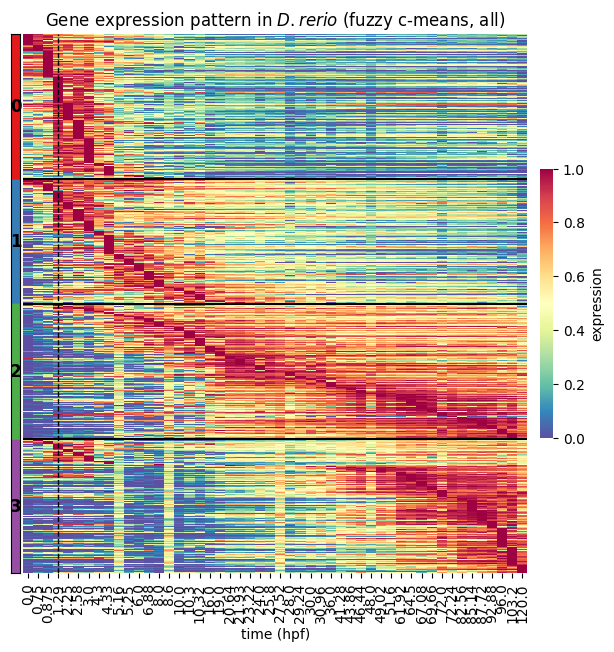

In [8]:
plot_heatmap_supercluster("clustering/results/all_gene_cluster_annotation_minmax.nc", cluster_col="supercluster", algo="fuzzy c-means", norm="minmax")

[debug] genes surviving normalisation: 6331 / 6331


C:\Users\mgrho\AppData\Local\Temp\ipykernel_35552\1182529315.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


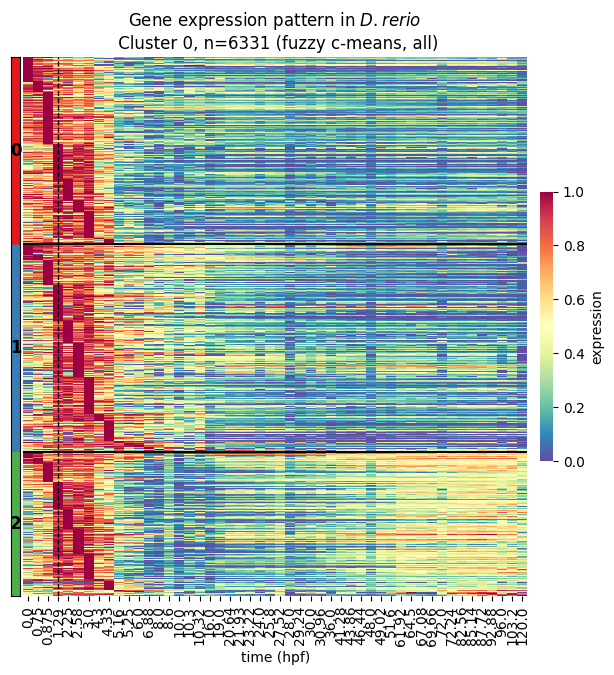

[debug] genes surviving normalisation: 5393 / 5393


C:\Users\mgrho\AppData\Local\Temp\ipykernel_35552\1182529315.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


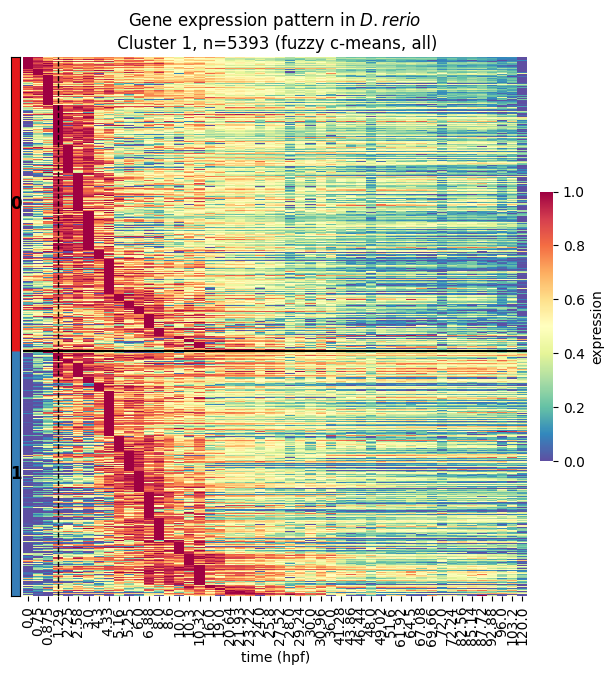

[debug] genes surviving normalisation: 5907 / 5907


C:\Users\mgrho\AppData\Local\Temp\ipykernel_35552\1182529315.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


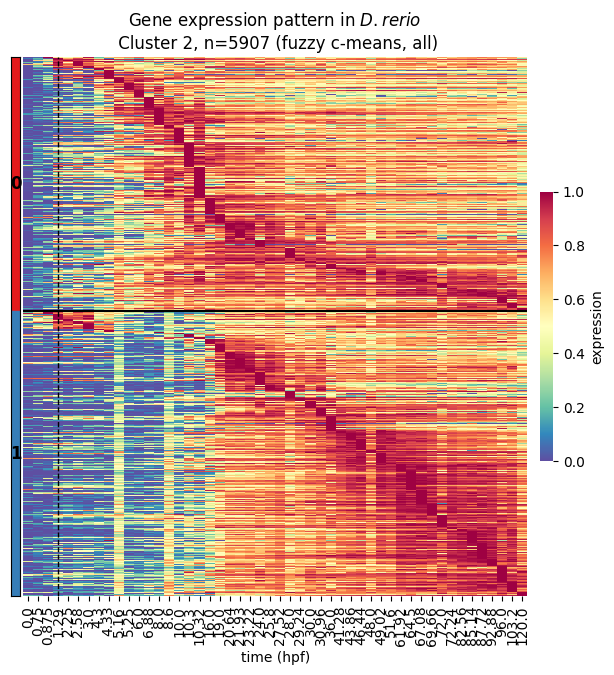

[debug] genes surviving normalisation: 5797 / 5797


C:\Users\mgrho\AppData\Local\Temp\ipykernel_35552\1182529315.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


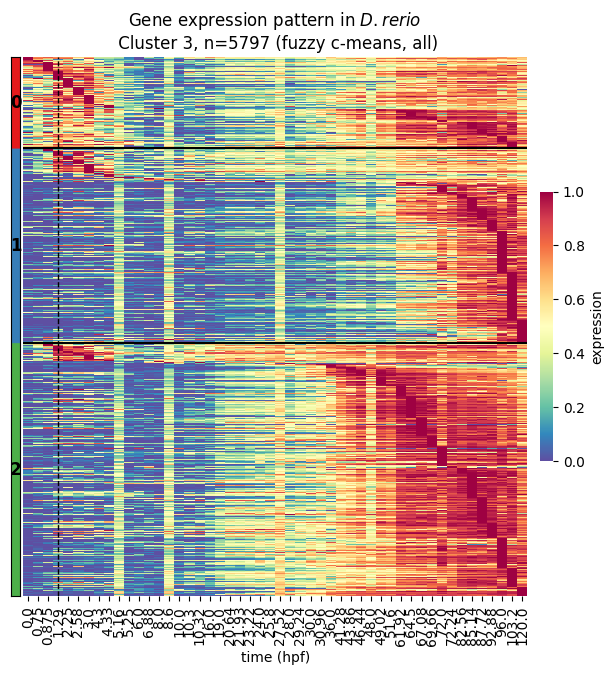

In [9]:
for i in range(4):
    plot_heatmap_supercluster("clustering/results/all_gene_cluster_annotation_minmax.nc", cluster_col="subcluster",
                algo="fuzzy c-means", source="all", supercluster=i)

## Model fit GOF

In [2]:
gof = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
params = pd.read_csv("results/results_summary/params_combined.csv")
params.head()

,gene_id,beta_mean,delta_mean,sigma_y_mean,beta_std,delta_std,sigma_y_std,supercluster,supercluster_no,subcluster_no,...,alpha_mean,delta_m_mean,delta_z_mean,t_rep_mean,t_zga_mean,alpha_std,delta_m_std,delta_z_std,t_rep_std,t_zga_std
0,ENSDARG00000000001,0.243,0.11800,0.498,0.2120,0.09420,0.0447,SD,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENSDARG00000000002,0.172,0.00851,0.420,0.0198,0.00368,0.0395,DSU,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENSDARG00000000018,30.600,1.01000,0.536,9.4400,0.31500,0.0504,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENSDARG00000000019,7.610,0.16000,0.266,1.3900,0.02610,0.0245,SD,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENSDARG00000000068,0.976,0.10000,0.640,0.3540,0.03030,0.0581,SD,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# result summary
with pd.ExcelWriter("results/evaluation_all.xlsx") as writer:
    gof.groupby(["model", "supercluster"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_all")
    gof.groupby(["model", "supercluster"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_all")
    gof_src.groupby(["model", "source"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_src")
    gof_src.groupby(["model", "source"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_src")
    gof_src.groupby(["model", "source", "supercluster"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_sc_src")
    gof_src.groupby(["model", "source", "supercluster"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_sc_src")


KeyboardInterrupt: 

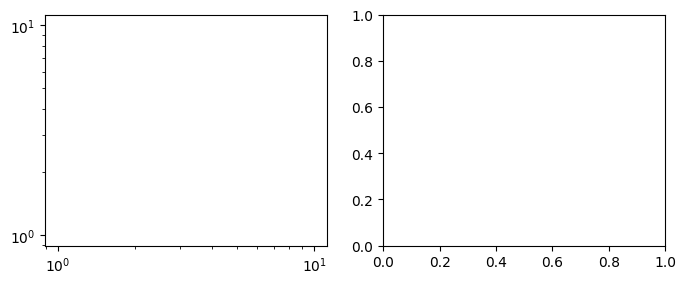

In [3]:
params = params[params["beta_mean"] > 1e-5]

rep_m = params[params["model"]=="Rep_M"]
rep_z = params[params["model"]=="Rep_Z"]

colors = sns.color_palette("Set1", n_colors=4)
fig, ax =plt.subplots(1,2, figsize=(8,3), sharey=False, sharex=False)
sns.kdeplot(rep_m, x="beta_mean", y="alpha_mean",  hue="supercluster", ax=ax[0], palette=colors, legend=False, log_scale=True, fill=False, )
sns.kdeplot(rep_z, x="beta_mean",  y="alpha_mean", hue="supercluster", ax=ax[1], palette=colors, legend=True, log_scale=True, fill=False, )
ax[0].set(xlabel="beta", ylabel="alpha", title="Rep M-decay",)#xscale="log", yscale="log", )
ax[1].set(xlabel="beta", ylabel="alpha", title="Rep Z-decay",)#xscale="log", yscale="log", )
sns.move_legend(ax[1], loc=(1.02, 0.1), frameon=False)
plt.tight_layout()
plt.show()

In [34]:
ds = xr.load_dataset("clustering/results/all_gene_cluster_annotation_minmax.nc").tpm.mean("source")
df = pd.DataFrame({"ensembl_gene_id": ds.ensembl_gene_id.values,
                   "supercluster_no":ds.supercluster.values,
                   "subluster_no":ds.subcluster.values,})
stats = xr.Dataset({"t_peak": ds.idxmax(dim="time"),})

stats_df = stats.to_dataframe().reset_index().drop(columns=["supercluster", "subcluster"])
df = df.merge(stats_df, on="ensembl_gene_id", how="left")

time = ds.time.values

In [ ]:
# load data and combine with supercluster assignment
gof_all = pd.read_csv("results/Basic/goodness_of_fit_summary.csv")
gof_src = pd.read_csv("results/Basic/gof_by_source_joined.csv")
params = pd.read_csv("results/Basic/parameter_fit_summary.csv")
supercluster = xr.load_dataset("clustering/results/all_gene_cluster_annotation_minmax.nc")

# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": supercluster["ensembl_gene_id"].values,
    "supercluster_no": supercluster["supercluster"].values,
    "subcluster_no": supercluster["subcluster"].values,
}).set_index("ensembl_gene_id")

cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}
lookup["supercluster"]=lookup["supercluster_no"].map(cluster_names)

# Map onto df by gene_id
for df in [gof_all, gof_src, params]:
    df["supercluster"] = df["gene_id"].map(lookup["supercluster"])
    df["supercluster_no"] = df["gene_id"].map(lookup["supercluster_no"])
    df["subcluster_no"] = df["gene_id"].map(lookup["subcluster_no"])
    df["model"] = "Basic"

gof_src.head()

C:\Users\mgrho\AppData\Local\Temp\ipykernel_35552\3041958923.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(cnt, palette=mod_color_dict)


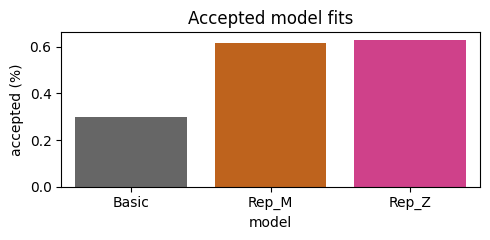

In [ ]:
def barplot_accepted(gof_all):

    gof = pd.read_csv("results/results_summary/gof_all_combined.csv")
    gof1 = gof[ (gof["NRMSE"] < 0.3) & (gof["rho"] > 0.6)]
    cnt = gof1.groupby("model").gene_id.count() / gof.groupby("model").gene_id.count()

    col_m = sns.color_palette("Dark2")  
    mod_color_dict = {"Basic": col_m[7],"Rep_M": col_m[1], "Rep_Z": col_m[3], "Rep_V": col_m[4]} 

    plt.figure(figsize=(5, 2.5))
    sns.barplot(cnt, palette=mod_color_dict)
    plt.ylabel("accepted (%)")
    plt.title("Accepted model fits")
    plt.tight_layout()
    plt.savefig(f"barplot_accepted.png", dpi=300)
    plt.show()

In [69]:
df_m.supercluster.value_counts()

supercluster
DSU    6650
SU     6450
SD     6390
DSD    5294
Name: count, dtype: int64

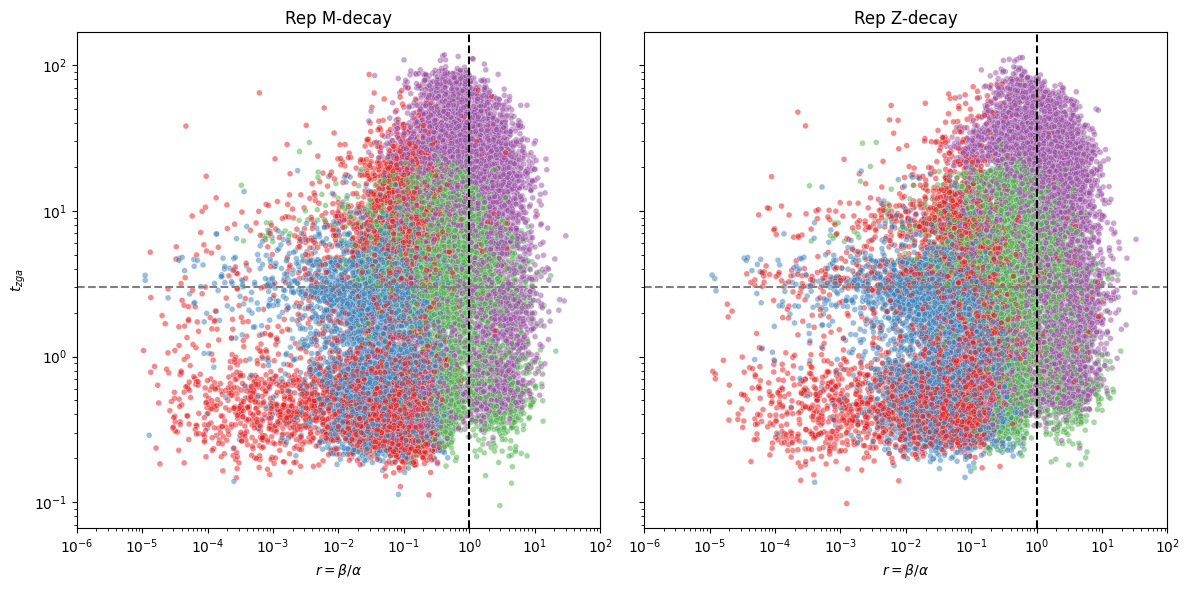

In [ ]:
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

df = params[params["model"] != "Basic"].copy()
df["r"] = df["beta_mean"] / df["alpha_mean"]
df = df[(df["r"] > 1e-5) & (df["t_zga_mean"] < 120)]

df_z = df[df["model"] == "Rep_Z"].copy()
df_m = df[df["model"] == "Rep_M"].copy()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)
sns.scatterplot(df_m, x="r", y="t_zga_mean", ax=ax1,  hue="supercluster", size=1, palette=cluster_color_dict, alpha=0.5, legend=False)
sns.scatterplot(df_z, x="r", y="t_zga_mean", ax=ax2, hue="supercluster", size=1, palette=cluster_color_dict, alpha=0.5, legend=False)

#sns.kdeplot(df_m, x="r", y="t_zga_mean",  hue="supercluster", ax=ax1, palette=cluster_color_dict, legend=True, log_scale=True, fill=False, levels=4)
#sns.kdeplot(df_z, x="r",  y="t_zga_mean", hue="supercluster", ax=ax2, palette=cluster_color_dict, legend=True, log_scale=True, fill=False, levels=4)

ax1.set(xlabel= "$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title="Rep M-decay", xscale="log", yscale="log", xlim=(1e-6, 1e2), )
ax2.set(xlabel="$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title="Rep Z-decay", xscale="log", yscale="log", xlim=(1e-6, 1e2), )

ax1.axvline(1, c="k", ls="--")
ax2.axvline(1, c="k", ls="--")

ax1.axhline(3, c="gray", ls="--", label="ZGA")
ax2.axhline(3, c="gray", ls="--", label="ZGA")

plt.tight_layout()
plt.show()

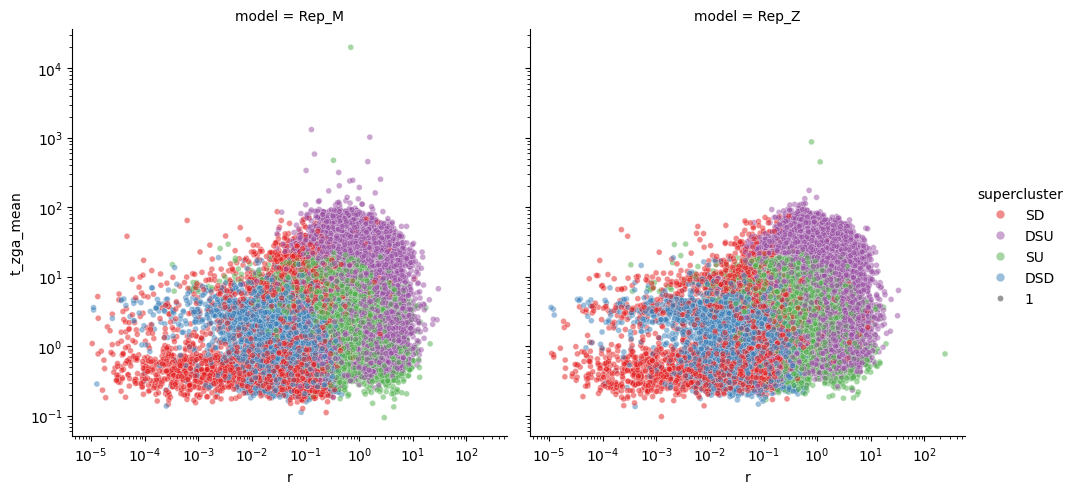

In [80]:
sns.relplot(df, x="r", y="t_zga_mean", col="model", hue="supercluster", size=1, palette=cluster_color_dict, alpha=0.5, legend=True)
plt.xscale("log")
plt.yscale("log")

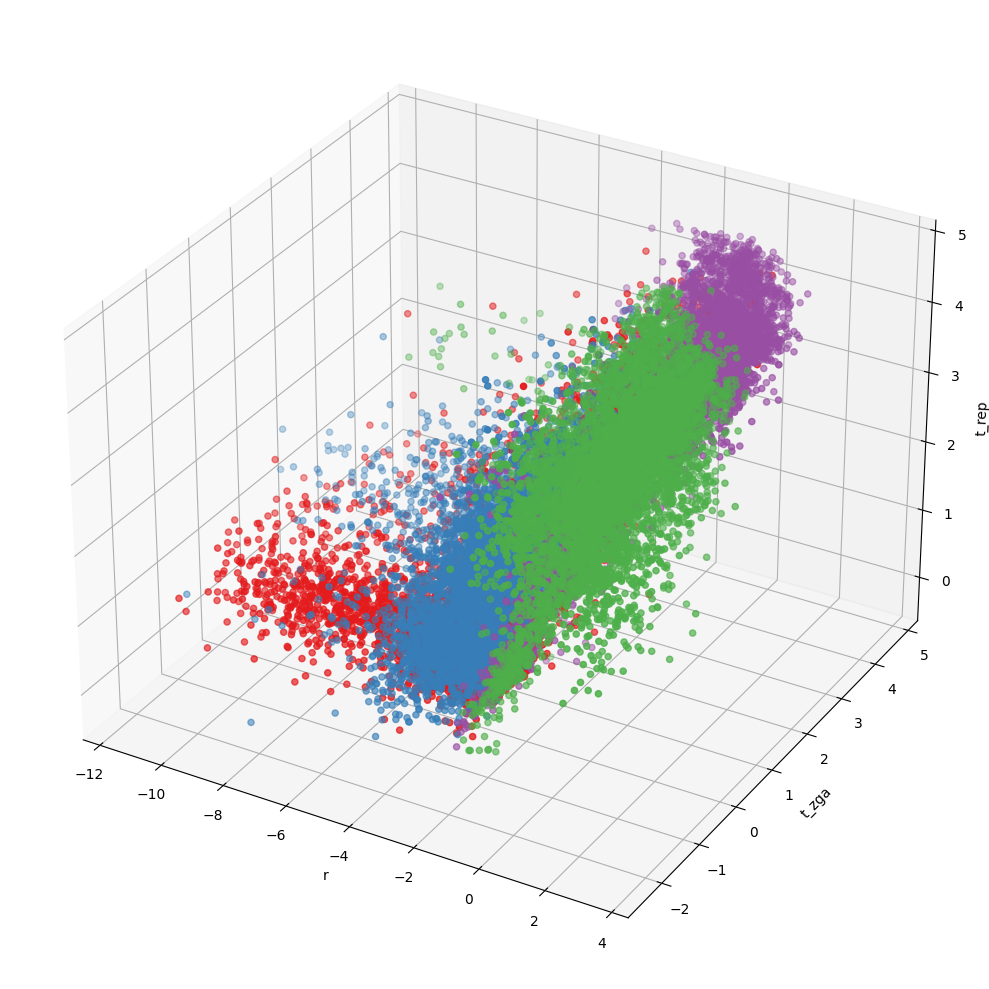

In [19]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')

df = params[params["model"] != "Basic"].copy()
df["r"] = df["beta_mean"] / df["alpha_mean"]
df = df[(df["r"] > 1e-5) & (df["t_zga_mean"] < 120) & (df["t_rep_mean"] < 120)]

df_z = df[df["model"] == "Rep_Z"].copy()
df_m = df[df["model"] == "Rep_M"].copy()


df_m = df_m.dropna(subset=["supercluster"])

df_m["r"] = np.log(df_m["r"])
df_m["t_zga_mean"] = np.log(df_m["t_zga_mean"])
df_m["t_rep_mean"] = np.log(df_m["t_rep_mean"])

for sc in df_m.supercluster.unique():
    df_m1 = df_m[df_m["supercluster"] == sc].copy()
    ax.scatter(df_m1["r"], df_m1["t_zga_mean"], df_m1["t_rep_mean"], color=cluster_color_dict[sc], label=sc)
       
ax.set_xlabel('r')
ax.set_ylabel('t_zga')
ax.set_zlabel('t_rep')
plt.tight_layout()
plt.show()

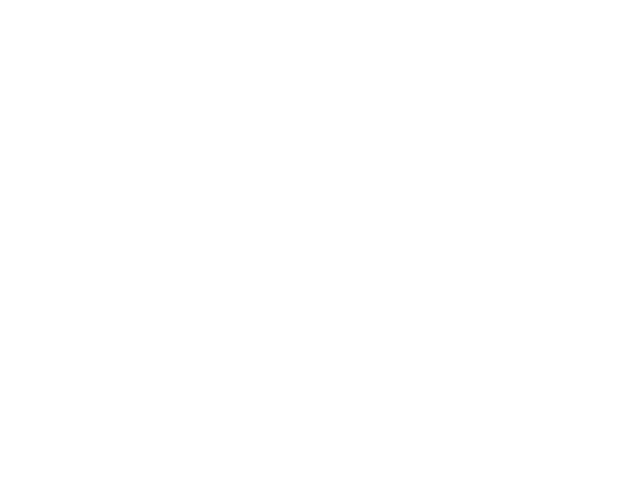

In [ ]:
# importing required libraries
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = Axes3D(fig)

for sc in df_m.supercluster.unique():
    df_m1 = df_m[df_m["supercluster"] == sc].copy()
    plot = ax.scatter(df_m1["r"].values, df_m1["t_zga_mean"].values, df_m1["t_rep_mean"].values, color=cluster_color_dict[sc])
plt.show()

c:\Users\mgrho\anaconda3\envs\thesis2\Lib\site-packages\upsetplot\data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\mgrho\anaconda3\envs\thesis2\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

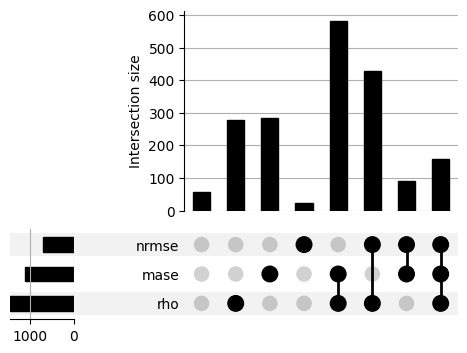

In [ ]:
from upsetplot import plot
from matplotlib import pyplot
from upsetplot import from_memberships


gof_src
example = from_memberships(
    [[],
     ['mase'],
     ['rho'],
     ['mase', 'rho'],
     ['nrmse'],
     ['mase', 'nrmse'],
     ['rho', 'nrmse'],
     ['mase', 'rho', 'nrmse'],
     ],
     data=[56, 283, 279, 582, 24, 90, 429, 157]
)

plot(example)